# Fase 1 — Preparação dos dados e EDA

Notebook inicial do projeto. Aqui carregamos o arquivo original da Literary Digest e organizamos a estrutura da aba 1936 antes de qualquer limpeza.

## 1. Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Caminho e carregamento da base

Carregamos o arquivo original sem alterá-lo.

In [2]:
RAW_PATH = "../data/raw/LitDigestFull.xlsx"
xls = pd.ExcelFile(RAW_PATH)
xls.sheet_names

['1924', '1928', '1932', '1936']

## 3. Inspeção das abas

In [3]:
for sheet in ["1932", "1936"]:
    shape = pd.read_excel(xls, sheet_name=sheet, header=None).shape
    print(sheet, shape)

1932 (53, 45)
1936 (52, 56)


Antes de montar os cabeçalhos, olhamos as primeiras linhas da aba 1936 sem nenhuma interpretação, só para confirmar a estrutura encontrada na auditoria.

In [4]:
raw_1936 = pd.read_excel(xls, sheet_name="1936", header=None)
raw_1936.iloc[0:5, 0:12]

,0,1,2,3,4,5,6,7,8,9,10,11
0,NaN,NaN,Landon (R),How did they vote in 1932?,NaN,NaN,NaN,NaN,NaN,NaN,Roosevelt (D),How did they vote in 1932?
1,State,Electoral Vote,Landon,Rep.,Dem.,Soc.,Others,Did Not Vote,Vote Not Indicated,NaN,Roosevelt (D),Rep.
2,Alabama,11,3060,1218,1298,3,3,412,126,NaN,10082,371
3,Arizona,3,2337,1431,647,18,0,129,112,NaN,1975,248
4,Arkansas,9,2724,1338,953,7,9,274,143,NaN,7608,228


A linha 0 traz rótulos de grupo (Landon, Roosevelt...), a linha 1 traz os nomes de coluna, e os dados dos estados começam na linha 2. O bloco de resultados oficiais começa em outra faixa de colunas e não segue esse mesmo padrão de cabeçalho.

## 4. Separação dos blocos de 1936

A pesquisa Literary Digest (colunas A:AG) tem cabeçalho em duas linhas, com rótulos de grupo que aparecem uma única vez por bloco de candidato. Os resultados oficiais (colunas AI:BC) têm cabeçalho em uma linha só, mas repetem nomes como "Electoral votes" e "%" várias vezes — não dá para usar esse cabeçalho direto sem colisão de nomes.

Por isso os nomes de coluna de cada bloco foram definidos manualmente, coluna por coluna, com base na auditoria já feita. A coluna BD (link de fonte) e as colunas separadoras vazias (J, R, Z, AH) ficam de fora.

In [5]:
poll_col_letters = "A,B,C,D:I,K,L:Q,S,T:Y,AA:AG"
poll_columns = [
    "state", "electoral_vote", "landon",
    "landon_1932_rep", "landon_1932_dem", "landon_1932_soc",
    "landon_1932_others", "landon_1932_did_not_vote", "landon_1932_vote_not_indicated",
    "roosevelt",
    "roosevelt_1932_rep", "roosevelt_1932_dem", "roosevelt_1932_soc",
    "roosevelt_1932_others", "roosevelt_1932_did_not_vote", "roosevelt_1932_vote_not_indicated",
    "lemke",
    "lemke_1932_rep", "lemke_1932_dem", "lemke_1932_soc",
    "lemke_1932_others", "lemke_1932_did_not_vote", "lemke_1932_vote_not_indicated",
    "thomas", "browder", "colvin", "aiken", "others_minor", "minor_total", "grand_total",
]

# skiprows=2 pula as duas linhas de cabeçalho; nrows=50 cobre os 48 estados + State Unknown + Totals
df_poll_1936 = pd.read_excel(
    xls, sheet_name="1936", header=None, skiprows=2, nrows=50,
    usecols=poll_col_letters, names=poll_columns,
)
df_poll_1936.shape

(50, 30)

In [6]:
official_col_letters = "AI:BC"
official_columns = [
    "state", "electoral_votes_total",
    "roosevelt_votes", "roosevelt_pct", "roosevelt_electoral_votes",
    "landon_votes", "landon_pct", "landon_electoral_votes",
    "lemke_votes", "lemke_pct", "lemke_electoral_votes",
    "thomas_votes", "thomas_pct", "thomas_electoral_votes",
    "other_votes", "other_pct", "other_electoral_votes",
    "margin", "margin_pct", "total_votes", "state_abbr",
]

# skiprows=1 pula a única linha de cabeçalho; nrows=50 cobre os 48 estados + linha vazia + TOTALS:
df_actual_1936 = pd.read_excel(
    xls, sheet_name="1936", header=None, skiprows=1, nrows=50,
    usecols=official_col_letters, names=official_columns,
)
df_actual_1936.shape

(50, 21)

## 5. Inspeção inicial

### Bloco da pesquisa (df_poll_1936)

In [7]:
df_poll_1936.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   state                              50 non-null     str  
 1   electoral_vote                     50 non-null     int64
 2   landon                             50 non-null     int64
 3   landon_1932_rep                    50 non-null     int64
 4   landon_1932_dem                    50 non-null     int64
 5   landon_1932_soc                    50 non-null     int64
 6   landon_1932_others                 50 non-null     int64
 7   landon_1932_did_not_vote           50 non-null     int64
 8   landon_1932_vote_not_indicated     50 non-null     int64
 9   roosevelt                          50 non-null     int64
 10  roosevelt_1932_rep                 50 non-null     int64
 11  roosevelt_1932_dem                 50 non-null     int64
 12  roosevelt_1932_soc                 

In [8]:
df_poll_1936.head()

,state,electoral_vote,landon,landon_1932_rep,landon_1932_dem,landon_1932_soc,landon_1932_others,landon_1932_did_not_vote,landon_1932_vote_not_indicated,roosevelt,...,lemke_1932_others,lemke_1932_did_not_vote,lemke_1932_vote_not_indicated,thomas,browder,colvin,aiken,others_minor,minor_total,grand_total
0,Alabama,11,3060,1218,1298,3,3,412,126,10082,...,0,4,6,33,3,27,0,0,63,13273
1,Arizona,3,2337,1431,647,18,0,129,112,1975,...,0,10,12,22,24,14,0,0,60,4476
2,Arkansas,9,2724,1338,953,7,9,274,143,7608,...,3,9,10,37,5,21,2,5,70,10540
3,California,22,89516,65360,16200,315,53,3519,4069,77245,...,25,163,492,728,967,398,44,60,2197,173935
4,Colorado,6,15949,11872,2714,131,12,637,583,10025,...,2,26,53,122,49,41,10,11,233,26786


In [9]:
# linhas finais: aqui devem aparecer "State Unknown" e "Totals"
df_poll_1936.tail(3)

,state,electoral_vote,landon,landon_1932_rep,landon_1932_dem,landon_1932_soc,landon_1932_others,landon_1932_did_not_vote,landon_1932_vote_not_indicated,roosevelt,...,lemke_1932_others,lemke_1932_did_not_vote,lemke_1932_vote_not_indicated,thomas,browder,colvin,aiken,others_minor,minor_total,grand_total
47,Wyoming,3,2526,1830,510,15,1,83,87,1533,...,1,4,4,11,2,2,0,0,15,4152
48,State Unknown,0,7158,4763,1416,35,5,263,676,6545,...,1,35,103,67,38,52,8,2,167,14563
49,Totals,531,1293669,920225,250059,5629,825,61323,55608,972897,...,223,3679,6773,11822,9485,3771,683,586,26347,2376523


In [10]:
# nulos por coluna no bloco da pesquisa
df_poll_1936.isna().sum()

state                                0
electoral_vote                       0
landon                               0
landon_1932_rep                      0
landon_1932_dem                      0
landon_1932_soc                      0
landon_1932_others                   0
landon_1932_did_not_vote             0
landon_1932_vote_not_indicated       0
roosevelt                            0
roosevelt_1932_rep                   0
roosevelt_1932_dem                   0
roosevelt_1932_soc                   0
roosevelt_1932_others                0
roosevelt_1932_did_not_vote          0
roosevelt_1932_vote_not_indicated    0
lemke                                0
lemke_1932_rep                       0
lemke_1932_dem                       0
lemke_1932_soc                       0
lemke_1932_others                    0
lemke_1932_did_not_vote              0
lemke_1932_vote_not_indicated        0
thomas                               0
browder                              0
colvin                   

### Bloco oficial (df_actual_1936)

In [11]:
df_actual_1936.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   state                      49 non-null     str    
 1   electoral_votes_total      49 non-null     float64
 2   roosevelt_votes            49 non-null     float64
 3   roosevelt_pct              49 non-null     float64
 4   roosevelt_electoral_votes  49 non-null     object 
 5   landon_votes               49 non-null     float64
 6   landon_pct                 49 non-null     float64
 7   landon_electoral_votes     49 non-null     object 
 8   lemke_votes                49 non-null     object 
 9   lemke_pct                  49 non-null     object 
 10  lemke_electoral_votes      49 non-null     str    
 11  thomas_votes               49 non-null     object 
 12  thomas_pct                 49 non-null     object 
 13  thomas_electoral_votes     49 non-null     str    
 14  other_v

In [12]:
df_actual_1936.head()

,state,electoral_votes_total,roosevelt_votes,roosevelt_pct,roosevelt_electoral_votes,landon_votes,landon_pct,landon_electoral_votes,lemke_votes,lemke_pct,...,thomas_votes,thomas_pct,thomas_electoral_votes,other_votes,other_pct,other_electoral_votes,margin,margin_pct,total_votes,state_abbr
0,Alabama,11.0,238136.0,86.38,11,35358.0,12.82,-,551,0.2,...,242,0.09,-,1397,0.51,-,202838.0,73.56,275244.0,AL
1,Arizona,3.0,86722.0,69.85,3,33433.0,26.93,-,3307,2.66,...,317,0.26,-,384,0.31,-,53289.0,42.92,124163.0,AZ
2,Arkansas,9.0,146765.0,81.80,9,32039.0,17.86,-,4,0,...,446,0.25,-,169,0.09,-,114726.0,63.94,179423.0,AR
3,California,22.0,1766836.0,66.95,22,836431.0,31.70,-,-,-,...,11331,0.43,-,24284,0.92,-,930405.0,35.26,2638882.0,CA
4,Colorado,6.0,295021.0,60.37,6,181267.0,37.09,-,9962,2.04,...,1593,0.33,-,841,0.17,-,113754.0,23.28,488684.0,CO


In [13]:
# linhas finais: aqui deve aparecer a linha vazia separadora e "TOTALS:"
df_actual_1936.tail(3)

,state,electoral_votes_total,roosevelt_votes,roosevelt_pct,roosevelt_electoral_votes,landon_votes,landon_pct,landon_electoral_votes,lemke_votes,lemke_pct,...,thomas_votes,thomas_pct,thomas_electoral_votes,other_votes,other_pct,other_electoral_votes,margin,margin_pct,total_votes,state_abbr
47,Wyoming,3.0,62624.0,60.58,3,38739.0,37.47,-,1653,1.6,...,200,0.19,-,166,0.16,-,23885.0,23.10,103382.0,WY
48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49,TOTALS:,531.0,27752648.0,60.80,523,16681862.0,36.54,8,892378,1.95,...,187910,0.41,-,132901,0.29,-,11070786.0,24.25,45647699.0,US


In [14]:
# nulos por coluna no bloco oficial — o "-" ainda está como texto, não como NaN
df_actual_1936.isna().sum()

state                        1
electoral_votes_total        1
roosevelt_votes              1
roosevelt_pct                1
roosevelt_electoral_votes    1
landon_votes                 1
landon_pct                   1
landon_electoral_votes       1
lemke_votes                  1
lemke_pct                    1
lemke_electoral_votes        1
thomas_votes                 1
thomas_pct                   1
thomas_electoral_votes       1
other_votes                  1
other_pct                    1
other_electoral_votes        1
margin                       1
margin_pct                   1
total_votes                  1
state_abbr                   1
dtype: int64

### Linhas especiais

Identificação explícita das linhas que não representam um estado comum, sem removê-las ainda.

In [15]:
state_unknown_row = df_poll_1936[df_poll_1936["state"] == "State Unknown"]
totals_row_poll = df_poll_1936[df_poll_1936["state"] == "Totals"]
totals_row_actual = df_actual_1936[df_actual_1936["state"] == "TOTALS:"]

print("State Unknown encontrada:", len(state_unknown_row) == 1)
print("Totals (pesquisa) encontrada:", len(totals_row_poll) == 1)
print("TOTALS: (oficial) encontrada:", len(totals_row_actual) == 1)

State Unknown encontrada: True
Totals (pesquisa) encontrada: True
TOTALS: (oficial) encontrada: True


## 6. Validação estrutural inicial

Checagens básicas para confirmar que os dois blocos foram lidos corretamente antes de qualquer limpeza.

In [16]:
# colunas principais presentes nos dois blocos
assert set(poll_columns).issubset(df_poll_1936.columns)
assert set(official_columns).issubset(df_actual_1936.columns)
print("Colunas esperadas presentes nos dois blocos: OK")

Colunas esperadas presentes nos dois blocos: OK


In [17]:
# 48 estados em cada bloco, sem duplicidade
states_poll = df_poll_1936.loc[~df_poll_1936["state"].isin(["State Unknown", "Totals"]), "state"]
states_actual = df_actual_1936.loc[
    df_actual_1936["state"].notna() & (df_actual_1936["state"] != "TOTALS:"), "state"
]

assert len(states_poll) == 48, f"esperado 48 estados na pesquisa, encontrado {len(states_poll)}"
assert len(states_actual) == 48, f"esperado 48 estados no bloco oficial, encontrado {len(states_actual)}"
assert states_poll.is_unique, "nomes de estado duplicados no bloco da pesquisa"
assert states_actual.is_unique, "nomes de estado duplicados no bloco oficial"
print("48 estados confirmados nos dois blocos, sem duplicidade")

48 estados confirmados nos dois blocos, sem duplicidade


In [18]:
# os dois blocos precisam falar dos mesmos estados
assert set(states_poll) == set(states_actual), "nomes de estado divergem entre os dois blocos"
print("Nomes de estado batem entre pesquisa e resultados oficiais: OK")

Nomes de estado batem entre pesquisa e resultados oficiais: OK


In [19]:
# presença das linhas especiais já identificadas acima
assert "State Unknown" in df_poll_1936["state"].values
assert "Totals" in df_poll_1936["state"].values
assert "TOTALS:" in df_actual_1936["state"].values
print("Linhas especiais presentes nos dois blocos: OK")

Linhas especiais presentes nos dois blocos: OK

Estrutura conferida: os dois blocos estão separados corretamente, com os 48 estados identificados e as linhas especiais localizadas. A limpeza (tratamento do "-" no bloco oficial, junção dos dois blocos por estado, remoção das linhas especiais da análise estadual) fica para a próxima etapa.

## 7. Limpeza do bloco Literary Digest

Agora vamos retirar as linhas auxiliares ("State Unknown" e "Totals") e deixar somente os 48 estados que entram na análise. As duas linhas removidas não são descartadas — ficam guardadas à parte.

In [20]:
# confere se as colunas quantitativas do bloco da pesquisa têm só valores numéricos
poll_numeric_cols = [c for c in poll_columns if c != "state"]

unexpected_values = {}
for c in poll_numeric_cols:
    mask = ~df_poll_1936[c].apply(lambda v: isinstance(v, (int, float, np.integer, np.floating)))
    if mask.any():
        unexpected_values[c] = df_poll_1936.loc[mask, ["state", c]]

print("Colunas com valor não numérico inesperado:", list(unexpected_values.keys()))

Colunas com valor não numérico inesperado: []


In [21]:
df_poll_1936_unknown = df_poll_1936[df_poll_1936["state"] == "State Unknown"].copy()
df_poll_1936_totals = df_poll_1936[df_poll_1936["state"] == "Totals"].copy()

df_poll_1936_clean = (
    df_poll_1936[~df_poll_1936["state"].isin(["State Unknown", "Totals"])]
    .reset_index(drop=True)
    .copy()
)

df_poll_1936_clean[poll_numeric_cols] = df_poll_1936_clean[poll_numeric_cols].astype("int64")

df_poll_1936_clean.shape, df_poll_1936_unknown.shape, df_poll_1936_totals.shape

((48, 30), (1, 30), (1, 30))

## 8. Limpeza do bloco oficial

Aqui retiramos a linha vazia separadora e a linha "TOTALS:", guardando o total à parte para validação.

In [22]:
df_actual_1936_totals = df_actual_1936[df_actual_1936["state"] == "TOTALS:"].copy()

df_actual_1936_clean = (
    df_actual_1936[df_actual_1936["state"].notna() & (df_actual_1936["state"] != "TOTALS:")]
    .reset_index(drop=True)
    .copy()
)

df_actual_1936_clean.shape, df_actual_1936_totals.shape

((48, 21), (1, 21))

### Tratamento do "-"

O "-" aparece em duas situações diferentes no bloco oficial. Nas colunas de eleitores do colégio eleitoral por candidato, "-" significa que o candidato não venceu o estado — vira 0. Nas colunas de votos e percentual dos candidatos menores, o "-" fica como está: ainda não sabemos se representa zero ou ausência de registro, então essa conversão não é feita agora.

In [23]:
electoral_vote_cols = [
    "roosevelt_electoral_votes",
    "landon_electoral_votes",
    "lemke_electoral_votes",
    "thomas_electoral_votes",
    "other_electoral_votes",
]

# confirma que o único valor não numérico nessas colunas é o "-", antes de converter
for c in electoral_vote_cols:
    mask = ~df_actual_1936_clean[c].apply(lambda v: isinstance(v, (int, float, np.integer, np.floating)))
    print(c, "valores não numéricos encontrados:", df_actual_1936_clean.loc[mask, c].unique())

roosevelt_electoral_votes valores não numéricos encontrados: ['-']
landon_electoral_votes valores não numéricos encontrados: ['-']
lemke_electoral_votes valores não numéricos encontrados: <StringArray>
['-']
Length: 1, dtype: str
thomas_electoral_votes valores não numéricos encontrados: <StringArray>
['-']
Length: 1, dtype: str
other_electoral_votes valores não numéricos encontrados: <StringArray>
['-']
Length: 1, dtype: str


In [24]:
for c in electoral_vote_cols:
    df_actual_1936_clean[c] = df_actual_1936_clean[c].replace("-", 0).astype("int64")

df_actual_1936_clean[electoral_vote_cols].dtypes

roosevelt_electoral_votes    int64
landon_electoral_votes       int64
lemke_electoral_votes        int64
thomas_electoral_votes       int64
other_electoral_votes        int64
dtype: object

In [25]:
# colunas de votos/percentual dos candidatos menores: "-" mantido, pendência registrada
pending_dash_cols = [
    "lemke_votes", "lemke_pct",
    "thomas_votes", "thomas_pct",
    "other_votes", "other_pct",
]

for c in pending_dash_cols:
    mask = ~df_actual_1936_clean[c].apply(lambda v: isinstance(v, (int, float, np.integer, np.floating)))
    print(c, "valores não numéricos:", df_actual_1936_clean.loc[mask, c].unique(), "| ocorrências:", mask.sum())

lemke_votes valores não numéricos: ['-'] | ocorrências: 11
lemke_pct valores não numéricos: ['-'] | ocorrências: 11
thomas_votes valores não numéricos: ['-'] | ocorrências: 10
thomas_pct valores não numéricos: ['-'] | ocorrências: 10
other_votes valores não numéricos: ['-'] | ocorrências: 8
other_pct valores não numéricos: ['-'] | ocorrências: 8


In [26]:
# demais colunas numéricas do bloco oficial (sem "-", já vieram limpas)
actual_whole_number_cols = ["electoral_votes_total", "roosevelt_votes", "landon_votes", "margin", "total_votes"]
df_actual_1936_clean[actual_whole_number_cols] = df_actual_1936_clean[actual_whole_number_cols].astype("int64")

df_actual_1936_clean.dtypes

state                            str
electoral_votes_total          int64
roosevelt_votes                int64
roosevelt_pct                float64
roosevelt_electoral_votes      int64
landon_votes                   int64
landon_pct                   float64
landon_electoral_votes         int64
lemke_votes                   object
lemke_pct                     object
lemke_electoral_votes          int64
thomas_votes                  object
thomas_pct                    object
thomas_electoral_votes         int64
other_votes                   object
other_pct                     object
other_electoral_votes          int64
margin                         int64
margin_pct                   float64
total_votes                    int64
state_abbr                       str
dtype: object

## 9. Junção dos blocos

Cruzamos os dois blocos limpos pelo nome do estado, com indicador de correspondência para conferir se algum estado ficou de fora.

In [27]:
df_1936_analysis = df_poll_1936_clean.merge(
    df_actual_1936_clean,
    on="state",
    how="outer",
    indicator=True,
)

df_1936_analysis["_merge"].value_counts()

_merge
both          48
left_only      0
right_only     0
Name: count, dtype: int64

In [28]:
assert len(df_poll_1936_clean) == 48, "bloco da pesquisa não tem 48 estados"
assert len(df_actual_1936_clean) == 48, "bloco oficial não tem 48 estados"
assert len(df_1936_analysis) == 48, "base cruzada não tem 48 estados"
assert df_1936_analysis["state"].is_unique, "estado duplicado após o merge"
assert (df_1936_analysis["_merge"] == "both").all(), "existe estado sem correspondência entre os blocos"

df_1936_analysis = df_1936_analysis.drop(columns="_merge")
print("Junção validada: 48 estados, sem duplicidade, sem estado sem correspondência.")

Junção validada: 48 estados, sem duplicidade, sem estado sem correspondência.


## 10. Validação dos totais da pesquisa

Para cada estado: Landon + Roosevelt + Lemke + candidatos menores deve bater com o Grand Total.

In [29]:
minor_cols = ["thomas", "browder", "colvin", "aiken", "others_minor"]

minor_candidates_sum = df_1936_analysis[minor_cols].sum(axis=1)
totals_check_sum = (
    df_1936_analysis["landon"] + df_1936_analysis["roosevelt"] + df_1936_analysis["lemke"] + minor_candidates_sum
)
totals_check_ok = totals_check_sum == df_1936_analysis["grand_total"]

n_ok = int(totals_check_ok.sum())
n_fail = int((~totals_check_ok).sum())
print(f"Estados OK: {n_ok} | Estados com divergência: {n_fail}")

if n_fail:
    diverging = df_1936_analysis.loc[~totals_check_ok, ["state", "landon", "roosevelt", "lemke", "grand_total"]].copy()
    diverging["minor_candidates_sum"] = minor_candidates_sum[~totals_check_ok]
    diverging["computed_total"] = totals_check_sum[~totals_check_ok]
    display(diverging)

Estados OK: 48 | Estados com divergência: 0


In [30]:
# checagem cruzada com a linha "Totals" original da pesquisa
grand_total_sum_48_states = df_poll_1936_clean["grand_total"].sum()
grand_total_reference = int(df_poll_1936_totals["grand_total"].iloc[0])
state_unknown_grand_total = int(df_poll_1936_unknown["grand_total"].iloc[0])

print("Soma de grand_total pelos 48 estados:", grand_total_sum_48_states)
print("Valor da linha 'Totals' original:", grand_total_reference)
print("Bate direto (sem 'State Unknown'):", grand_total_sum_48_states == grand_total_reference)
print()
print("grand_total de 'State Unknown':", state_unknown_grand_total)
print(
    "48 estados + 'State Unknown' bate com a linha 'Totals' original:",
    grand_total_sum_48_states + state_unknown_grand_total == grand_total_reference,
)

Soma de grand_total pelos 48 estados: 2361960
Valor da linha 'Totals' original: 2376523
Bate direto (sem 'State Unknown'): False

grand_total de 'State Unknown': 14563
48 estados + 'State Unknown' bate com a linha 'Totals' original: True


## 11. Proporções

Duas visões para Landon e Roosevelt: sobre o total de respondentes e considerando só os dois principais candidatos. Antes de dividir, conferimos se algum estado teria denominador zero.

In [31]:
zero_grand_total = df_1936_analysis[df_1936_analysis["grand_total"] == 0]
zero_two_party = df_1936_analysis[(df_1936_analysis["landon"] + df_1936_analysis["roosevelt"]) == 0]

print("Estados com grand_total = 0:", len(zero_grand_total))
print("Estados com landon + roosevelt = 0:", len(zero_two_party))

Estados com grand_total = 0: 0
Estados com landon + roosevelt = 0: 0


In [32]:
df_1936_analysis["landon_share_total"] = df_1936_analysis["landon"] / df_1936_analysis["grand_total"]
df_1936_analysis["roosevelt_share_total"] = df_1936_analysis["roosevelt"] / df_1936_analysis["grand_total"]

two_party_total = df_1936_analysis["landon"] + df_1936_analysis["roosevelt"]
df_1936_analysis["landon_share_two_party"] = df_1936_analysis["landon"] / two_party_total
df_1936_analysis["roosevelt_share_two_party"] = df_1936_analysis["roosevelt"] / two_party_total

df_1936_analysis[[
    "state", "landon_share_total", "roosevelt_share_total",
    "landon_share_two_party", "roosevelt_share_two_party",
]].head()

,state,landon_share_total,roosevelt_share_total,landon_share_two_party,roosevelt_share_two_party
0,Alabama,0.230543,0.759587,0.232841,0.767159
1,Arizona,0.522118,0.441242,0.541976,0.458024
2,Arkansas,0.258444,0.721822,0.263647,0.736353
3,California,0.514652,0.444103,0.536792,0.463208
4,Colorado,0.595423,0.374263,0.614037,0.385963


## 12. Validação das proporções

In [33]:
# a soma das duas shares sobre o total deve bater com (landon + roosevelt) / grand_total
combined_share_direct = (df_1936_analysis["landon"] + df_1936_analysis["roosevelt"]) / df_1936_analysis["grand_total"]
combined_share_from_columns = df_1936_analysis["landon_share_total"] + df_1936_analysis["roosevelt_share_total"]

coherent_total_share = np.isclose(combined_share_direct, combined_share_from_columns).all()
print("landon_share_total + roosevelt_share_total coerente com (landon+roosevelt)/grand_total:", coherent_total_share)

landon_share_total + roosevelt_share_total coerente com (landon+roosevelt)/grand_total: True


In [34]:
# landon_share_two_party + roosevelt_share_two_party deve ser aproximadamente 1 nos 48 estados
two_party_sum = df_1936_analysis["landon_share_two_party"] + df_1936_analysis["roosevelt_share_two_party"]
two_party_ok = np.isclose(two_party_sum, 1.0).all()
print("landon_share_two_party + roosevelt_share_two_party ≈ 1 em todos os estados:", two_party_ok)

landon_share_two_party + roosevelt_share_two_party ≈ 1 em todos os estados: True


## 13. Exportação

As bases preparadas vão para `data/processed/`. Antes de salvar, conferimos que não sobrou nenhuma coluna auxiliar de validação nos DataFrames finais.

In [35]:
print("df_poll_1936_clean:", df_poll_1936_clean.shape)
print("df_actual_1936_clean:", df_actual_1936_clean.shape)
print("df_1936_analysis:", df_1936_analysis.shape)
print()
print("Colunas df_1936_analysis:", list(df_1936_analysis.columns))

df_poll_1936_clean: (48, 30)
df_actual_1936_clean: (48, 21)
df_1936_analysis: (48, 54)

Colunas df_1936_analysis: ['state', 'electoral_vote', 'landon', 'landon_1932_rep', 'landon_1932_dem', 'landon_1932_soc', 'landon_1932_others', 'landon_1932_did_not_vote', 'landon_1932_vote_not_indicated', 'roosevelt', 'roosevelt_1932_rep', 'roosevelt_1932_dem', 'roosevelt_1932_soc', 'roosevelt_1932_others', 'roosevelt_1932_did_not_vote', 'roosevelt_1932_vote_not_indicated', 'lemke', 'lemke_1932_rep', 'lemke_1932_dem', 'lemke_1932_soc', 'lemke_1932_others', 'lemke_1932_did_not_vote', 'lemke_1932_vote_not_indicated', 'thomas', 'browder', 'colvin', 'aiken', 'others_minor', 'minor_total', 'grand_total', 'electoral_votes_total', 'roosevelt_votes', 'roosevelt_pct', 'roosevelt_electoral_votes', 'landon_votes', 'landon_pct', 'landon_electoral_votes', 'lemke_votes', 'lemke_pct', 'lemke_electoral_votes', 'thomas_votes', 'thomas_pct', 'thomas_electoral_votes', 'other_votes', 'other_pct', 'other_electoral_votes

In [36]:
PROCESSED_DIR = "../data/processed"

df_poll_1936_clean.to_csv(f"{PROCESSED_DIR}/poll_1936_clean.csv", index=False)
df_actual_1936_clean.to_csv(f"{PROCESSED_DIR}/actual_1936_clean.csv", index=False)
df_1936_analysis.to_csv(f"{PROCESSED_DIR}/analysis_1936.csv", index=False)

print("CSVs salvos em", PROCESSED_DIR)

CSVs salvos em ../data/processed


Bases limpas, cruzadas, validadas e exportadas. As pendências sobre o "-" nas colunas de candidatos menores do bloco oficial continuam em aberto para a próxima etapa. Nenhuma análise de viés, gráfico final ou modelagem foi feita ainda.

## 14. EDA inicial

A partir daqui trabalhamos com a base já cruzada e validada, carregada direto de `analysis_1936.csv`.

In [37]:
df_1936_analysis = pd.read_csv("../data/processed/analysis_1936.csv")
df_1936_analysis.shape

(48, 54)

## 15. Visão geral da pesquisa

Estatísticas descritivas do tamanho da pesquisa e dos votos por candidato, por estado.

In [38]:
summary_cols = ["grand_total", "landon", "roosevelt", "lemke", "minor_total"]
df_1936_analysis[summary_cols].describe().loc[["mean", "50%", "min", "max"]]

,grand_total,landon,roosevelt,lemke,minor_total
mean,49207.5,26802.3125,20132.333333,1727.4375,545.416667
50%,25498.0,11744.5000,12342.500000,596.5000,163.000000
min,2013.0,848.0000,955.000000,20.0000,15.000000
max,323635.0,162260.0000,139277.000000,14656.0000,7442.000000


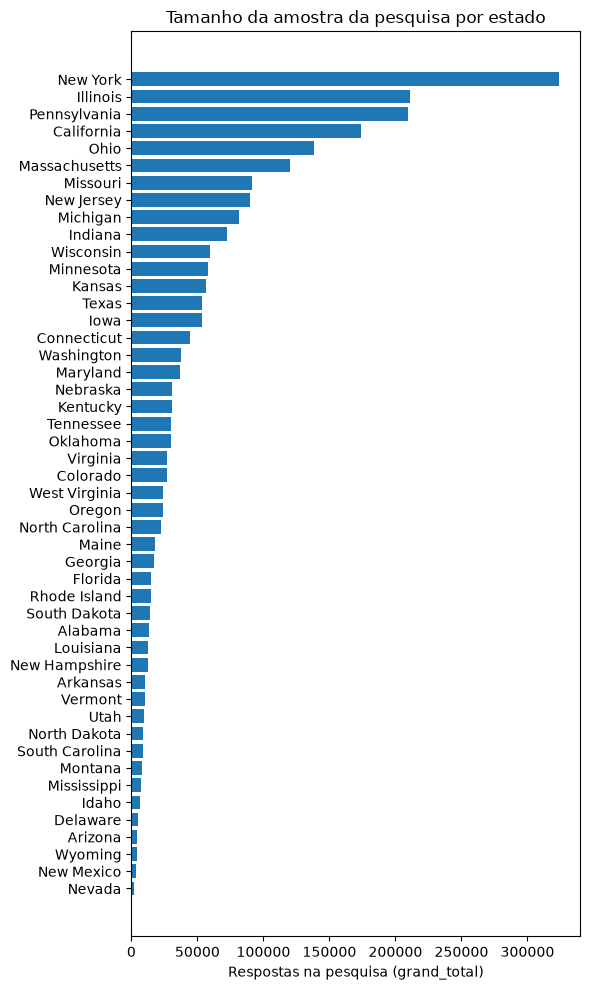

In [39]:
ordered_total = df_1936_analysis.sort_values("grand_total", ascending=True)

fig, ax = plt.subplots(figsize=(6, 10))
ax.barh(ordered_total["state"], ordered_total["grand_total"], color="tab:blue")
ax.set_xlabel("Respostas na pesquisa (grand_total)")
ax.set_title("Tamanho da amostra da pesquisa por estado")
plt.tight_layout()
plt.show()

## 16. Participação dos candidatos

Comparação Landon x Roosevelt por estado, usando a participação entre os dois principais candidatos (`landon_share_two_party` / `roosevelt_share_two_party`).

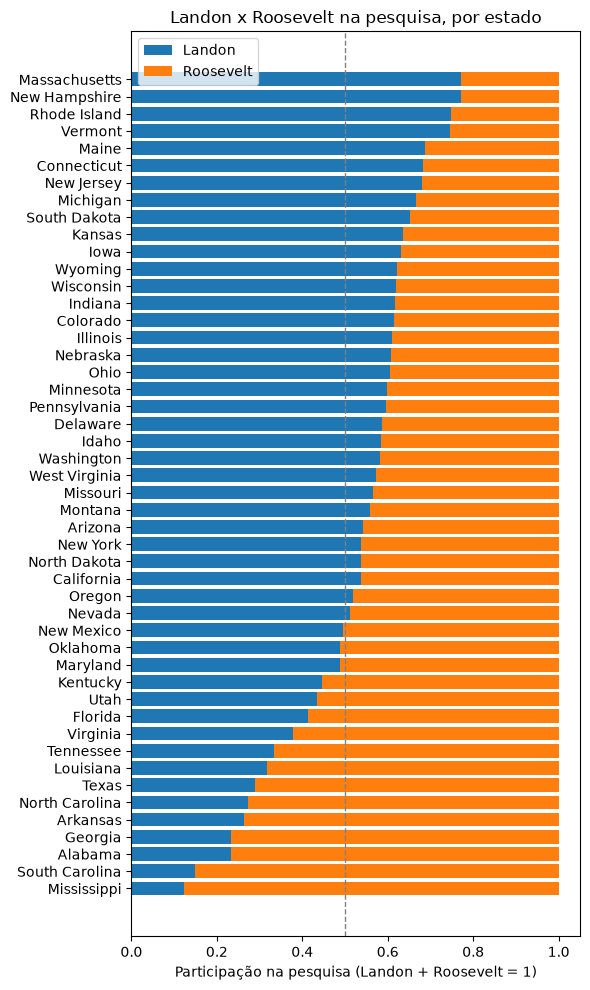

In [40]:
ordered_share = df_1936_analysis.sort_values("landon_share_two_party", ascending=True)

fig, ax = plt.subplots(figsize=(6, 10))
ax.barh(ordered_share["state"], ordered_share["landon_share_two_party"], color="tab:blue", label="Landon")
ax.barh(
    ordered_share["state"],
    ordered_share["roosevelt_share_two_party"],
    left=ordered_share["landon_share_two_party"],
    color="tab:orange",
    label="Roosevelt",
)
ax.axvline(0.5, color="gray", linewidth=1, linestyle="--")
ax.set_xlabel("Participação na pesquisa (Landon + Roosevelt = 1)")
ax.set_title("Landon x Roosevelt na pesquisa, por estado")
ax.legend()
plt.tight_layout()
plt.show()

## 17. Pesquisa x resultado oficial

Participação oficial de Landon e Roosevelt, calculada diretamente a partir dos votos oficiais (só os dois principais candidatos, para ficar na mesma base da pesquisa).

In [41]:
df_1936_analysis["actual_landon_share"] = df_1936_analysis["landon_votes"] / (
    df_1936_analysis["landon_votes"] + df_1936_analysis["roosevelt_votes"]
)
df_1936_analysis["actual_roosevelt_share"] = df_1936_analysis["roosevelt_votes"] / (
    df_1936_analysis["landon_votes"] + df_1936_analysis["roosevelt_votes"]
)

df_1936_analysis[["state", "actual_landon_share", "actual_roosevelt_share"]].head()

,state,actual_landon_share,actual_roosevelt_share
0,Alabama,0.129283,0.870717
1,Arizona,0.278249,0.721751
2,Arkansas,0.179185,0.820815
3,California,0.321301,0.678699
4,Colorado,0.380583,0.619417


`landon_error` e `roosevelt_error` são a diferença entre a participação na pesquisa e a participação no resultado oficial (pesquisa - real).

In [42]:
df_1936_analysis["landon_error"] = (
    df_1936_analysis["landon_share_two_party"] - df_1936_analysis["actual_landon_share"]
)
df_1936_analysis["roosevelt_error"] = (
    df_1936_analysis["roosevelt_share_two_party"] - df_1936_analysis["actual_roosevelt_share"]
)

df_1936_analysis[["state", "landon_share_two_party", "actual_landon_share", "landon_error"]].head()

,state,landon_share_two_party,actual_landon_share,landon_error
0,Alabama,0.232841,0.129283,0.103559
1,Arizona,0.541976,0.278249,0.263727
2,Arkansas,0.263647,0.179185,0.084462
3,California,0.536792,0.321301,0.215492
4,Colorado,0.614037,0.380583,0.233454


## 18. Distribuição dos erros

In [43]:
df_1936_analysis[["landon_error", "roosevelt_error"]].describe().loc[["mean", "50%", "min", "max"]]

,landon_error,roosevelt_error
mean,0.186204,-0.186204
50%,0.191289,-0.191289
min,0.006456,-0.321928
max,0.321928,-0.006456


In [44]:
# roosevelt_error é sempre o espelho de landon_error, já que as duas participações somam 1 nos dois casos
mirror_check = np.allclose(df_1936_analysis["roosevelt_error"], -df_1936_analysis["landon_error"])
print("roosevelt_error = -landon_error em todos os estados:", mirror_check)

roosevelt_error = -landon_error em todos os estados: True


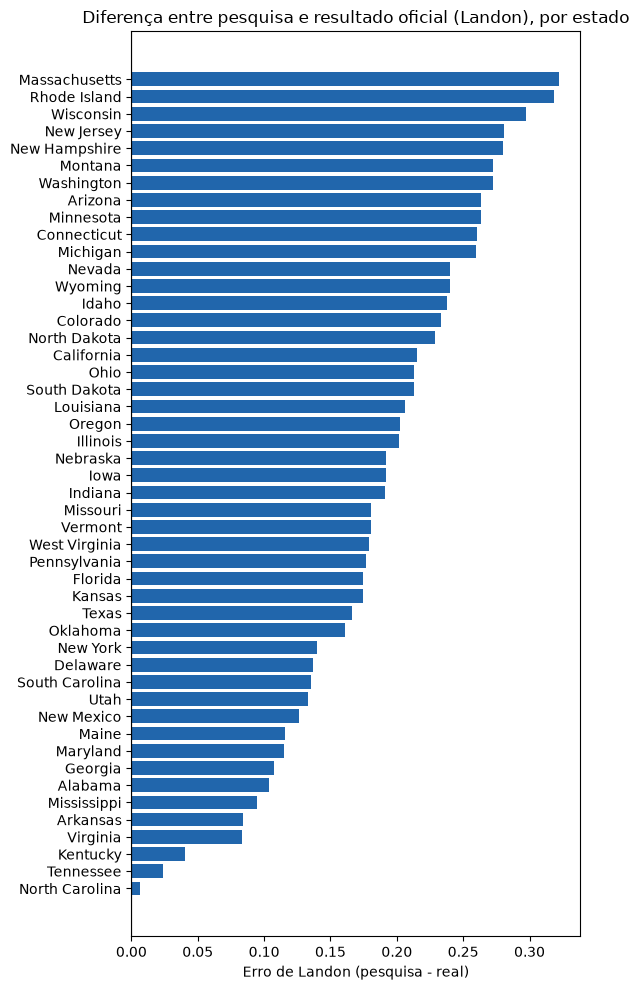

In [45]:
error_plot_df = df_1936_analysis[["state", "landon_error"]].sort_values("landon_error")
bar_colors = error_plot_df["landon_error"].apply(lambda v: "#b2182b" if v < 0 else "#2166ac")

fig, ax = plt.subplots(figsize=(6, 10))
ax.barh(error_plot_df["state"], error_plot_df["landon_error"], color=bar_colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Erro de Landon (pesquisa - real)")
ax.set_title("Diferença entre pesquisa e resultado oficial (Landon), por estado")
plt.tight_layout()
plt.show()

Como `roosevelt_error` é sempre o espelho de `landon_error` (confirmado acima), o mesmo gráfico já descreve os dois candidatos e um segundo gráfico para Roosevelt não acrescentaria informação nova.

## 19. Pesquisa x real (comparação direta)

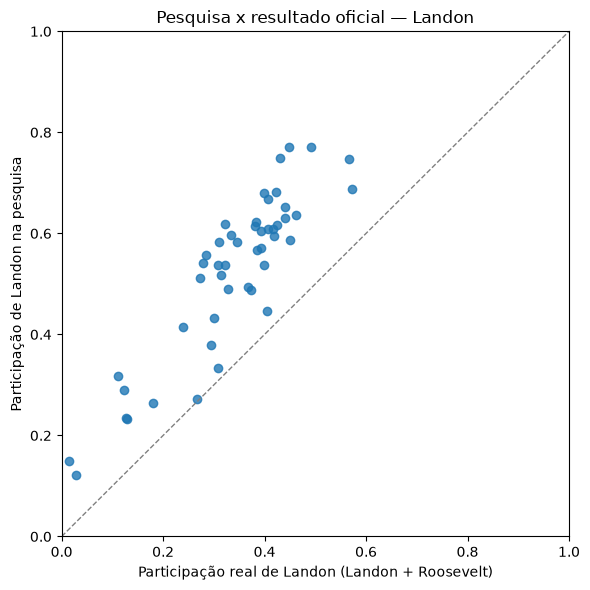

In [46]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
    df_1936_analysis["actual_landon_share"],
    df_1936_analysis["landon_share_two_party"],
    color="tab:blue",
    alpha=0.8,
)
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Participação real de Landon (Landon + Roosevelt)")
ax.set_ylabel("Participação de Landon na pesquisa")
ax.set_title("Pesquisa x resultado oficial — Landon")
plt.tight_layout()
plt.show()

A linha pontilhada é y = x (pesquisa igual ao resultado real), não uma previsão. Como Roosevelt é o espelho de Landon nas duas participações (1 - Landon), o mesmo gráfico giraria em torno da mesma diagonal e não muda a leitura — por isso não foi duplicado.

## 20. Tamanho da amostra x erro

In [47]:
df_1936_analysis["absolute_landon_error"] = df_1936_analysis["landon_error"].abs()

correlation = np.corrcoef(df_1936_analysis["grand_total"], df_1936_analysis["absolute_landon_error"])[0, 1]
print("Correlação (Pearson) entre grand_total e erro absoluto de Landon:", round(correlation, 3))

Correlação (Pearson) entre grand_total e erro absoluto de Landon: 0.099


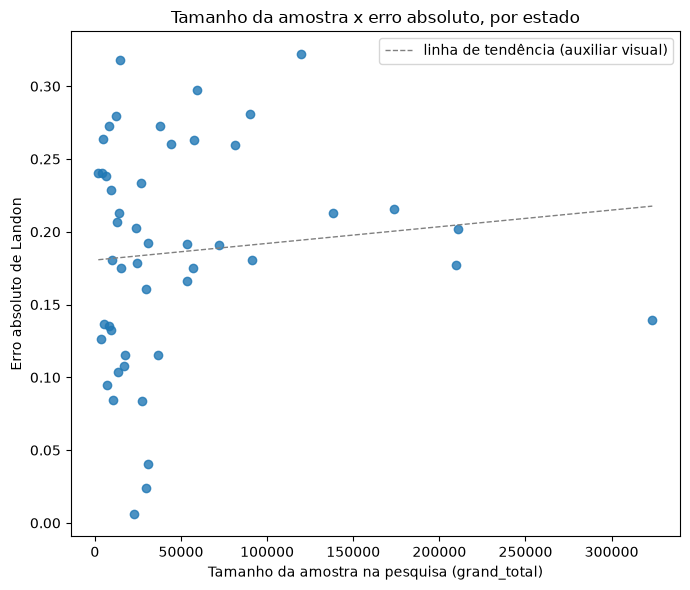

In [48]:
coeffs = np.polyfit(df_1936_analysis["grand_total"], df_1936_analysis["absolute_landon_error"], 1)
trend_x = np.linspace(df_1936_analysis["grand_total"].min(), df_1936_analysis["grand_total"].max(), 100)
trend_y = np.polyval(coeffs, trend_x)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df_1936_analysis["grand_total"], df_1936_analysis["absolute_landon_error"], color="tab:blue", alpha=0.8)
ax.plot(trend_x, trend_y, color="gray", linestyle="--", linewidth=1, label="linha de tendência (auxiliar visual)")
ax.set_xlabel("Tamanho da amostra na pesquisa (grand_total)")
ax.set_ylabel("Erro absoluto de Landon")
ax.set_title("Tamanho da amostra x erro absoluto, por estado")
ax.legend()
plt.tight_layout()
plt.show()

## 21. Observações da EDA

**Tamanho da amostra por estado:** varia de 2.013 respostas (Nevada) a 323.635 (New York), com mediana de 25.498 e média de 49.207 — a média fica bem acima da mediana porque alguns poucos estados grandes (New York, Illinois, Pennsylvania) concentram uma quantidade de respostas muito maior que a maioria.

**Pesquisa x resultado real:** em todos os 48 estados, `landon_error` foi positivo (mínimo 0,006, máximo 0,322, média 0,186). Ou seja, a participação de Landon na pesquisa ficou acima da participação oficial de Landon em todo o país, sem exceção — e, por espelho, a de Roosevelt ficou subestimada em todos os estados também.

**Onde o erro é mais evidente:** os maiores valores de `landon_error` aparecem em Massachusetts (0,322), Rhode Island (0,318), Wisconsin (0,298), New Jersey (0,281) e New Hampshire (0,280). Os menores aparecem em North Carolina (0,006), Tennessee (0,024), Kentucky (0,041), Virginia (0,084) e Arkansas (0,084).

**Tamanho da amostra x erro:** a correlação de Pearson entre `grand_total` e `absolute_landon_error` foi de 0,099 — próxima de zero. O gráfico de dispersão não mostra um padrão visual evidente entre as duas variáveis nesta base. Não é possível, com o que foi calculado até aqui, afirmar que exista relação entre tamanho da amostra estadual e magnitude do erro.

## 22. Atualização da base de análise

`analysis_1936.csv` é atualizado com as colunas criadas nesta EDA (`actual_landon_share`, `actual_roosevelt_share`, `landon_error`, `roosevelt_error`, `absolute_landon_error`). `poll_1936_clean.csv` e `actual_1936_clean.csv` não são alterados.

In [49]:
df_1936_analysis.to_csv("../data/processed/analysis_1936.csv", index=False)
print("analysis_1936.csv atualizado,", df_1936_analysis.shape)

analysis_1936.csv atualizado, (48, 59)


## 23. Diagnóstico de viés de amostragem e não-resposta

Esta seção fecha o requisito da Fase 1 sobre viés de amostragem e não-resposta. Trabalha só com o comportamento declarado de 1932 já presente na pesquisa de 1936 — nenhum modelo, nenhuma correção. Isso é responsabilidade do Membro B na Fase 2.

In [50]:
poll_df = pd.read_csv("../data/processed/poll_1936_clean.csv")

candidate_1932_cols = {
    "landon": ["landon_1932_rep", "landon_1932_dem", "landon_1932_soc",
               "landon_1932_others", "landon_1932_did_not_vote", "landon_1932_vote_not_indicated"],
    "roosevelt": ["roosevelt_1932_rep", "roosevelt_1932_dem", "roosevelt_1932_soc",
                  "roosevelt_1932_others", "roosevelt_1932_did_not_vote", "roosevelt_1932_vote_not_indicated"],
    "lemke": ["lemke_1932_rep", "lemke_1932_dem", "lemke_1932_soc",
              "lemke_1932_others", "lemke_1932_did_not_vote", "lemke_1932_vote_not_indicated"],
}
categories = ["rep", "dem", "soc", "others", "did_not_vote", "vote_not_indicated"]

## 24. Parte 1 — Validação da composição por candidato

Para cada grupo (Landon, Roosevelt, Lemke), a soma das seis categorias de 1932 precisa bater com o total de respondentes do candidato em 1936.

In [51]:
for candidate, cols in candidate_1932_cols.items():
    computed_total = poll_df[cols].sum(axis=1)
    ok = computed_total == poll_df[candidate]
    print(f"{candidate}: estados OK = {ok.sum()} / divergentes = {(~ok).sum()}")
    if not ok.all():
        display(poll_df.loc[~ok, ["state", candidate] + cols])

landon: estados OK = 48 / divergentes = 0
roosevelt: estados OK = 48 / divergentes = 0
lemke: estados OK = 48 / divergentes = 0


## 25. Parte 2 — Não-resposta por grupo de 1936

"Did Not Vote" e "Vote Not Indicated" são categorias do comportamento declarado de 1932 — não é a mesma coisa que não resposta ao questionário de 1936. O que dá para calcular aqui é a proporção dessas duas categorias dentro de cada grupo de preferência de 1936, e como isso varia entre estados.

In [52]:
nonresponse_rows = []
for candidate, cols in candidate_1932_cols.items():
    dnv_share = poll_df[f"{candidate}_1932_did_not_vote"] / poll_df[candidate]
    vni_share = poll_df[f"{candidate}_1932_vote_not_indicated"] / poll_df[candidate]
    combined_share = dnv_share + vni_share

    nonresponse_rows.append({
        "candidate": candidate,
        "did_not_vote_mean": dnv_share.mean(), "did_not_vote_min": dnv_share.min(), "did_not_vote_max": dnv_share.max(),
        "vote_not_indicated_mean": vni_share.mean(), "vote_not_indicated_min": vni_share.min(), "vote_not_indicated_max": vni_share.max(),
        "combined_mean": combined_share.mean(), "combined_min": combined_share.min(), "combined_max": combined_share.max(),
    })

nonresponse_summary = pd.DataFrame(nonresponse_rows)
nonresponse_summary

,candidate,did_not_vote_mean,did_not_vote_min,did_not_vote_max,vote_not_indicated_mean,vote_not_indicated_min,vote_not_indicated_max,combined_mean,combined_min,combined_max
0,landon,0.062968,0.025412,0.240577,0.044720,0.032702,0.082059,0.107688,0.066254,0.297514
1,roosevelt,0.053583,0.026459,0.121487,0.040166,0.028529,0.103242,0.093749,0.059221,0.163221
2,lemke,0.057259,0.020882,0.171429,0.085786,0.027778,0.200000,0.143045,0.090487,0.300000


In [53]:
# proporção agregada (soma dos 48 estados), não média das médias
pooled_rows = []
for candidate, cols in candidate_1932_cols.items():
    candidate_total = poll_df[candidate].sum()
    pooled_rows.append({
        "candidate": candidate,
        "did_not_vote_share": poll_df[f"{candidate}_1932_did_not_vote"].sum() / candidate_total,
        "vote_not_indicated_share": poll_df[f"{candidate}_1932_vote_not_indicated"].sum() / candidate_total,
    })

pooled_nonresponse = pd.DataFrame(pooled_rows).set_index("candidate")
pooled_nonresponse["combined_share"] = pooled_nonresponse["did_not_vote_share"] + pooled_nonresponse["vote_not_indicated_share"]
pooled_nonresponse

,did_not_vote_share,vote_not_indicated_share,combined_share
candidate,,,
landon,0.047462,0.042698,0.090160
roosevelt,0.059066,0.040098,0.099165
lemke,0.043948,0.080442,0.124389


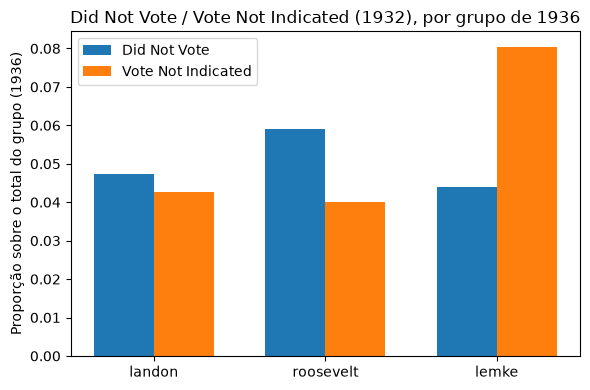

In [54]:
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(pooled_nonresponse))
width = 0.35
ax.bar(x - width / 2, pooled_nonresponse["did_not_vote_share"], width, label="Did Not Vote", color="tab:blue")
ax.bar(x + width / 2, pooled_nonresponse["vote_not_indicated_share"], width, label="Vote Not Indicated", color="tab:orange")
ax.set_xticks(x)
ax.set_xticklabels(pooled_nonresponse.index)
ax.set_ylabel("Proporção sobre o total do grupo (1936)")
ax.set_title("Did Not Vote / Vote Not Indicated (1932), por grupo de 1936")
ax.legend()
plt.tight_layout()
plt.show()

## 26. Parte 3 — Composição por estado (grupo Landon)

Heatmap simples: proporção de cada categoria de 1932 dentro dos respondentes Landon, estado por estado.

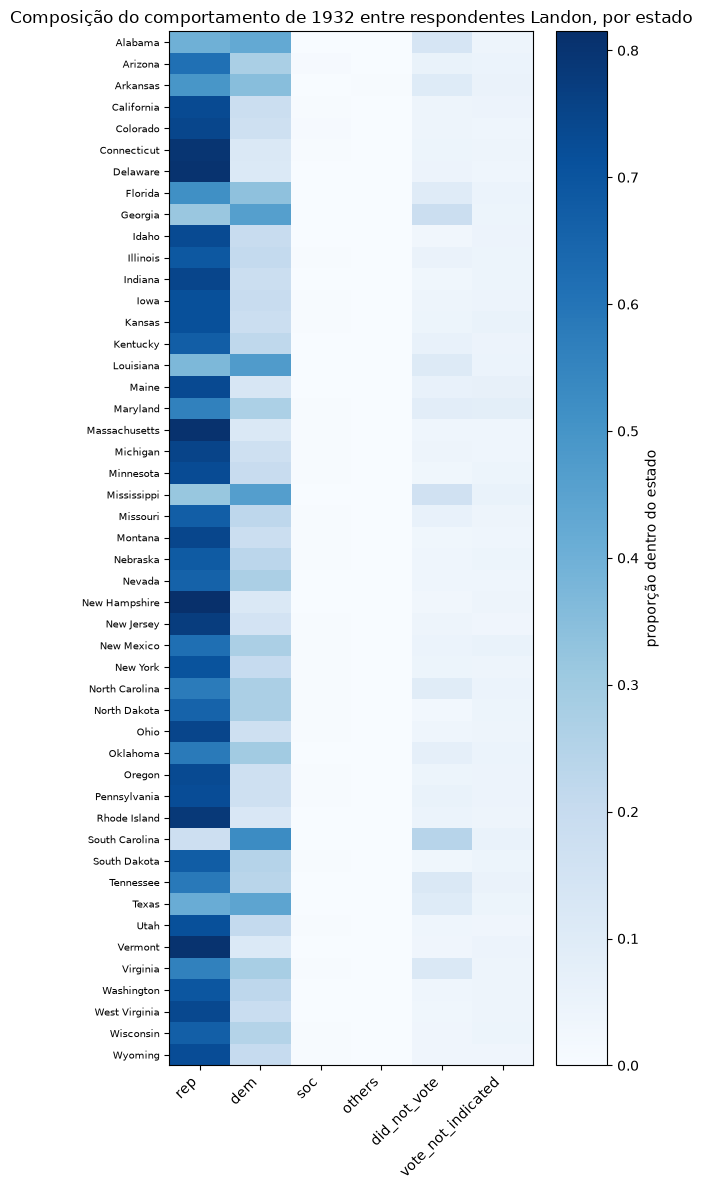

In [55]:
landon_props_by_state = poll_df[candidate_1932_cols["landon"]].div(poll_df["landon"], axis=0)
landon_props_by_state.columns = categories
landon_props_by_state.index = poll_df["state"]
landon_props_by_state = landon_props_by_state.sort_index()

fig, ax = plt.subplots(figsize=(6, 12))
im = ax.imshow(landon_props_by_state.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, rotation=45, ha="right")
ax.set_yticks(range(len(landon_props_by_state)))
ax.set_yticklabels(landon_props_by_state.index, fontsize=7)
ax.set_title("Composição do comportamento de 1932 entre respondentes Landon, por estado")
fig.colorbar(im, ax=ax, label="proporção dentro do estado")
plt.tight_layout()
plt.show()

## 27. Parte 4 — Landon x Roosevelt: diferença de composição

Comparação nacional (agregando os 48 estados) da composição de 1932 entre quem declarou Landon e quem declarou Roosevelt em 1936.

In [56]:
landon_agg = poll_df[candidate_1932_cols["landon"]].sum()
landon_agg.index = categories
landon_share_agg = landon_agg / poll_df["landon"].sum()

roosevelt_agg = poll_df[candidate_1932_cols["roosevelt"]].sum()
roosevelt_agg.index = categories
roosevelt_share_agg = roosevelt_agg / poll_df["roosevelt"].sum()

composition_comparison = pd.DataFrame({
    "landon_share": landon_share_agg,
    "roosevelt_share": roosevelt_share_agg,
})
composition_comparison["diff"] = composition_comparison["landon_share"] - composition_comparison["roosevelt_share"]
composition_comparison["abs_diff"] = composition_comparison["diff"].abs()
composition_comparison

,landon_share,roosevelt_share,diff,abs_diff
rep,0.711585,0.146963,0.564622,0.564622
dem,0.193269,0.734173,-0.540904,0.540904
soc,0.004348,0.018961,-0.014613,0.014613
others,0.000637,0.000738,-0.000100,0.000100
did_not_vote,0.047462,0.059066,-0.011605,0.011605
vote_not_indicated,0.042698,0.040098,0.002600,0.002600


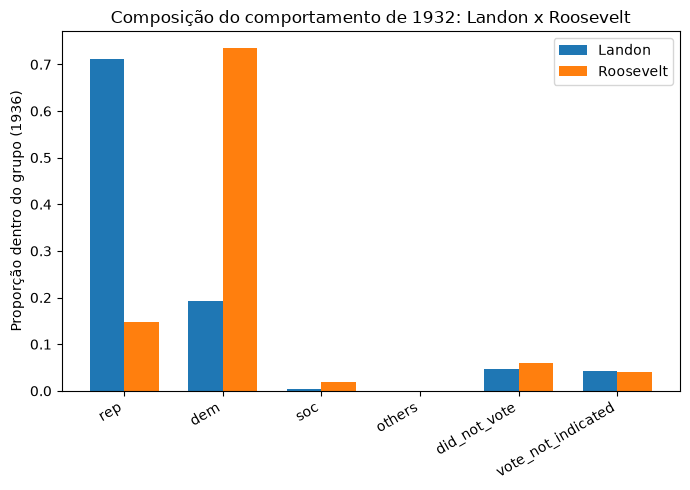

In [57]:
fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(categories))
width = 0.35
ax.bar(x - width / 2, composition_comparison["landon_share"], width, label="Landon", color="tab:blue")
ax.bar(x + width / 2, composition_comparison["roosevelt_share"], width, label="Roosevelt", color="tab:orange")
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=30, ha="right")
ax.set_ylabel("Proporção dentro do grupo (1936)")
ax.set_title("Composição do comportamento de 1932: Landon x Roosevelt")
ax.legend()
plt.tight_layout()
plt.show()

## 28. Parte 5 — Quantificação agregada da diferença

Medida agregada: **Total Variation Distance (TVD)**, `TVD = 0.5 * soma(|proporção_landon,c - proporção_roosevelt,c|)` somada sobre as 6 categorias. Varia de 0 (distribuições idênticas) a 1 (nenhuma sobreposição) e equivale à metade da soma das diferenças absolutas de proporção — é só isso, sem peso ou ajuste extra.

In [58]:
tvd_national = 0.5 * composition_comparison["abs_diff"].sum()
print("TVD nacional (Landon x Roosevelt, composição de 1932):", round(tvd_national, 4))

TVD nacional (Landon x Roosevelt, composição de 1932): 0.5672


## 29. Parte 6 — Composição x erro observado

Duas medidas de composição por estado: a TVD (Landon x Roosevelt) e a não-resposta combinada dentro do grupo Landon. As duas são comparadas com `landon_error`, já calculado na EDA. Correlação de Pearson é usada aqui só como estatística descritiva, sem regressão nem teste de hipótese.

In [59]:
landon_props_full = poll_df[candidate_1932_cols["landon"]].div(poll_df["landon"], axis=0)
roosevelt_props_full = poll_df[candidate_1932_cols["roosevelt"]].div(poll_df["roosevelt"], axis=0)
landon_props_full.columns = categories
roosevelt_props_full.columns = categories

state_tvd = 0.5 * (landon_props_full - roosevelt_props_full).abs().sum(axis=1)
state_tvd.index = poll_df["state"]
state_tvd.name = "composition_tvd"

landon_nonresponse_share = (
    poll_df["landon_1932_did_not_vote"] + poll_df["landon_1932_vote_not_indicated"]
) / poll_df["landon"]
landon_nonresponse_share.index = poll_df["state"]
landon_nonresponse_share.name = "landon_nonresponse_share"

composition_metrics = pd.concat([state_tvd, landon_nonresponse_share], axis=1).reset_index()
composition_metrics = composition_metrics.rename(columns={"index": "state"})

comp_error_df = composition_metrics.merge(df_1936_analysis[["state", "landon_error"]], on="state")
comp_error_df.head()

,state,composition_tvd,landon_nonresponse_share,landon_error
0,Alabama,0.425858,0.175817,0.103559
1,Arizona,0.519498,0.103124,0.263727
2,Arkansas,0.524884,0.153084,0.084462
3,California,0.539110,0.084767,0.215492
4,Colorado,0.578134,0.076494,0.233454


In [60]:
corr_tvd = np.corrcoef(comp_error_df["composition_tvd"], comp_error_df["landon_error"])[0, 1]
corr_nonresponse = np.corrcoef(comp_error_df["landon_nonresponse_share"], comp_error_df["landon_error"])[0, 1]

print("Correlação (Pearson) TVD Landon x Roosevelt vs landon_error:", round(corr_tvd, 3))
print("Correlação (Pearson) não-resposta Landon vs landon_error:", round(corr_nonresponse, 3))

Correlação (Pearson) TVD Landon x Roosevelt vs landon_error: 0.258
Correlação (Pearson) não-resposta Landon vs landon_error: -0.605


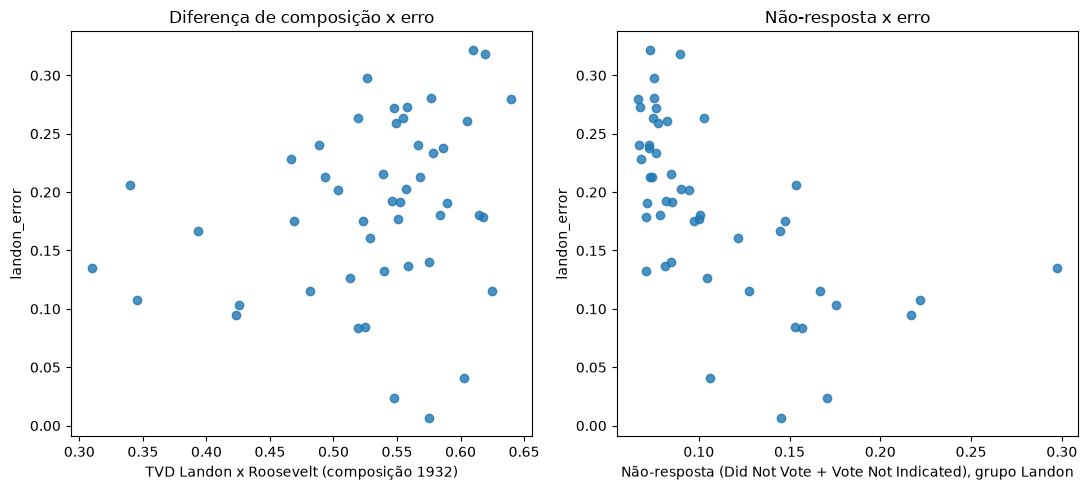

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].scatter(comp_error_df["composition_tvd"], comp_error_df["landon_error"], color="tab:blue", alpha=0.8)
axes[0].set_xlabel("TVD Landon x Roosevelt (composição 1932)")
axes[0].set_ylabel("landon_error")
axes[0].set_title("Diferença de composição x erro")

axes[1].scatter(comp_error_df["landon_nonresponse_share"], comp_error_df["landon_error"], color="tab:blue", alpha=0.8)
axes[1].set_xlabel("Não-resposta (Did Not Vote + Vote Not Indicated), grupo Landon")
axes[1].set_ylabel("landon_error")
axes[1].set_title("Não-resposta x erro")

plt.tight_layout()
plt.show()

## 30. Parte 7 — A aba 1932 pode servir de referência?

Antes de usar a aba 1932 do arquivo original como população de referência, é preciso conferir se ela tem a mesma estrutura das colunas de comportamento de 1932 já usadas acima.

In [62]:
raw_1932 = pd.read_excel(xls, sheet_name="1932", header=None)
raw_1932.iloc[0:3, 0:8]

,0,1,2,3,4,5,6,7
0,NaN,NaN,HOOVER,How the same Voters voted in 1928,NaN,NaN,NaN,NaN
1,NaN,Electoral Votes,1932 Total Vote,Rep.,Dem.,Other,Did Not Vote,NaN
2,ALABAMA,11,4272,3150,480,1,641,NaN


A aba 1932 é a pesquisa da Literary Digest **para a eleição de 1932** (Hoover x Roosevelt), com uma seção própria de resultados oficiais de 1932. As colunas de comportamento retrospectivo nessa aba (`How the same Voters voted in 1928`) têm só 4 categorias — Rep., Dem., Other, Did Not Vote — sem "Soc." separado e sem "Vote Not Indicated", diferente das 6 categorias usadas na aba 1936 para o comportamento de 1932.

Além disso, o bloco de resultados oficiais da aba 1932 traz votos reais por candidato (Hoover, Roosevelt, Thomas, Other) — população que votou de fato, sem categoria de "não votou" ou "não indicou o voto", porque isso não existe em resultado eleitoral oficial.

Ou seja: a aba 1932 não tem a mesma granularidade de categorias nem o mesmo denominador (eleitorado real x respondentes de uma pesquisa que recordam o próprio voto) da comparação feita acima. Por isso, a análise de composição desta seção fica como diagnóstico descritivo interno à pesquisa de 1936 (Landon x Roosevelt x Lemke), sem comparação direta com a aba 1932 como população de referência.

## 31. Parte 8 — Efeito de incluir "State Unknown" nos agregados nacionais

Os agregados nacionais das Partes 2, 4 e 5 somam só os 48 estados. Aqui conferimos se incluir "State Unknown" mudaria isso de forma relevante.

In [63]:
landon_totals_48 = poll_df[candidate_1932_cols["landon"]].sum()
landon_n_48 = poll_df["landon"].sum()
landon_share_48 = landon_totals_48 / landon_n_48

landon_totals_49 = landon_totals_48 + df_poll_1936_unknown[candidate_1932_cols["landon"]].iloc[0]
landon_n_49 = landon_n_48 + df_poll_1936_unknown["landon"].iloc[0]
landon_share_49 = landon_totals_49 / landon_n_49

diff_48_49_pp = (landon_share_49 - landon_share_48).abs() * 100
print("Diferença (pontos percentuais) ao incluir 'State Unknown', grupo Landon, por categoria:")
print(diff_48_49_pp.round(3))
print()
print("Maior diferença:", round(diff_48_49_pp.max(), 3), "pontos percentuais")

Diferença (pontos percentuais) ao incluir 'State Unknown', grupo Landon, por categoria:
landon_1932_rep                   0.026
landon_1932_dem                   0.003
landon_1932_soc                   0.000
landon_1932_others                0.000
landon_1932_did_not_vote          0.006
landon_1932_vote_not_indicated    0.029
dtype: float64

Maior diferença: 0.029 pontos percentuais


A diferença é pequena o bastante para não mudar a leitura dos resultados — por isso todos os agregados nacionais desta seção usam só os 48 estados, com "State Unknown" mantida separada (`df_poll_1936_unknown`), sem ser descartada.

## 32. Diagnóstico do viés

**FATO OBSERVADO**

A composição declarada de 1932 difere fortemente entre quem escolheu Landon e quem escolheu Roosevelt em 1936: 71,2% dos respondentes Landon disseram ter votado Republicano em 1932, contra 14,7% dos respondentes Roosevelt; e 73,4% dos respondentes Roosevelt disseram ter votado Democrata em 1932, contra 19,3% dos respondentes Landon. A TVD entre as duas distribuições de composição é 0,567.

A proporção combinada de "Did Not Vote" + "Vote Not Indicated" muda de ordem dependendo de como é calculada: somando os 48 estados, o grupo Landon tem a menor proporção combinada (9,0%), seguido por Roosevelt (9,9%) e Lemke (12,4%). Já pela média simples por estado (peso igual para cada estado), o grupo Landon tem a maior média (10,8%), acima de Roosevelt (9,4%) e abaixo de Lemke (14,3%). Essa inversão mostra que os estados maiores — que dominam a soma agregada — têm, no grupo Landon, uma proporção de não-resposta declarada menor do que a média dos estados pequenos.

Ao nível estadual, a correlação entre a TVD de composição (Landon x Roosevelt) e `landon_error` é de 0,258 (fraca). A correlação entre a não-resposta declarada do grupo Landon e `landon_error` é de -0,605 (moderada, negativa): estados em que o grupo Landon tem mais respostas "Did Not Vote"/"Vote Not Indicated" tendem a ter *menor* superestimação de Landon na pesquisa. Para comparação, a correlação entre tamanho da amostra (`grand_total`) e erro absoluto de Landon, calculada na EDA, foi de apenas 0,099.

**INTERPRETAÇÃO**

A diferença de composição entre os grupos Landon e Roosevelt é grande e consistente com uma base de respondentes que não é homogênea entre os dois candidatos — cada grupo carrega, em proporções muito diferentes, o próprio histórico eleitoral de 1932.

A associação negativa entre não-resposta declarada do grupo Landon e o erro vai na direção oposta do que uma hipótese simples de "mais não-resposta gera mais erro" previria nesta base. A quase ausência de relação entre tamanho da amostra e erro (0,099) sugere que o tamanho da amostra, isoladamente, não parece explicar por que a pesquisa errou mais em alguns estados do que em outros.

**LIMITAÇÃO**

Essas associações vêm de 48 observações (estados) e de correlação/diferenças descritivas — não isolam o efeito de uma variável mantendo as outras constantes, e não permitem causalidade.

A comparação de composição fica restrita aos próprios respondentes da pesquisa de 1936 (Landon x Roosevelt x Lemke). Como documentado na Parte 7, a aba 1932 do arquivo original não tem a mesma granularidade de categorias nem a mesma população de referência, então não foi usada como "verdade populacional" para validar se a composição da pesquisa está mais ou menos enviesada em relação à realidade de 1932.

Os dados não permitem, nesta etapa, atribuir o erro observado em 1936 a uma causa específica — nem à composição partidária declarada, nem à não-resposta, nem ao tamanho da amostra. Isso fica para investigação posterior, fora do escopo da Fase 1.

## 33. Exportação

Tabela de diagnóstico por estado (TVD de composição e não-resposta do grupo Landon, cruzada com o erro observado) salva para consulta futura. Nenhuma das bases já existentes (`poll_1936_clean.csv`, `actual_1936_clean.csv`) é alterada, e `analysis_1936.csv` não é sobrescrita nesta etapa.

In [64]:
comp_error_df.to_csv("../data/processed/bias_diagnostics_1936.csv", index=False)
print("bias_diagnostics_1936.csv salvo,", comp_error_df.shape)

bias_diagnostics_1936.csv salvo, (48, 4)
